# EDA — VAFC / tingia.gov.vn

Phân tích `vafc.json`: các nhóm tin giả/cảnh báo, thời gian, nhãn, chất lượng dữ liệu, độ dài nội dung và mẫu bài.

In [1]:
from pathlib import Path
import sys
search_roots = (Path.cwd(), *Path.cwd().parents)
module_dir = next((p for root in search_roots for p in (root, root / "loc_crawl" / "notebooks") if (p / "eda_utils.py").exists()), None)
if module_dir is None: raise FileNotFoundError("Không tìm thấy eda_utils.py")
sys.path.insert(0, str(module_dir))

from eda_utils import *
SOURCE_KEY = "vafc"
df, atomic_domains, data_path = load_source(SOURCE_KEY)
print(f"Đã tải {len(df):,} bài từ {data_path}")

Đã tải 485 bài từ C:\NC KHOA HỌC - THẦY LONG\Fact-checking\loc_crawl\output\vafc.json


## 1. Tổng quan và mẫu dữ liệu

In [2]:
overview = source_overview(df, atomic_domains, data_path)

**File:** `C:\NC KHOA HỌC - THẦY LONG\Fact-checking\loc_crawl\output\vafc.json`  
**Kích thước:** 1.77 MB

,Chỉ số,Giá trị
0,Số bài,485
1,Số domain nguyên bản,14
2,Số domain sau khi tách,14
3,Bài đa-domain,0
4,Ngày hợp lệ,485 (100.0%)
5,Ngày nhỏ nhất,2020-12-26
6,Ngày lớn nhất,2026-06-10
7,ID trùng,0
8,URL trùng,0


,id,source_name,domain,publish_date,claim,label,url
0,dd87a1c64cc2fe76f1ee4fac686293f7,VAFC,Công bố tin giả,2026-06-10,Lan truyền các video không rõ nguồn gốc để gây tổn hại đến uy tín của Suntory PepsiCo Việt Nam,FALSE,https://tingia.gov.vn/lan-truyen-cac-video-khong-ro-nguon-goc-de-gay-ton-hai-den-uy-tin-cua-sunt...
1,d24857503d9f8c4138d1f1ba9259aab0,VAFC,Quyền lợi người dân,2026-01-27,Thông tin sai sự thật về việc Omoda & Jaecoo,FALSE,https://tingia.gov.vn/o-n-j-tn.html
2,a858c8d354dac3af7d1981d4e4699993,VAFC,Quyền lợi người dân,2026-01-26,"Cảnh báo hành vi giả mạo, cắt ghép hình ảnh để quảng cáo lừa đảo tiền ảo, phát tán thông tin sai...",FALSE,https://tingia.gov.vn/cuc-du-lich.html
3,c92e41aa43872f50e4e578f710333431,VAFC,Quyền lợi người dân,2025-11-04,Cảnh báo về các hình thức lừa đảo và gian lận thương mại tại UAE,FALSE,https://tingia.gov.vn/canh-bao-ve-cac-hinh-thuc-lua-dao-va-gian-lan-thuong-mai-tai-uae.html
4,a83896ee66fadfefb20c05938dd1e710,VAFC,Quyền lợi người dân,2025-10-13,Thông tin xuyên tạc về “Tây Ninh đón đầu tư 10 tỷ USD từ Trung Quốc”,FALSE,https://tingia.gov.vn/thong-tin-xuyen-tac-ve-tay-ninh-don-dau-tu-10-ty-usd-tu-trung-quoc.html


## 2. Phân bố domain

**Phân bố domain sau khi tách dấu `;`**

,domain,số_bài,tỷ_lệ_trên_bài
0,Cảnh báo tin giả sitemap,159,0.33
1,Vaccine tin giả,125,0.26
2,Multimedia,111,0.23
3,Công bố tin giả,51,0.11
4,Quyền lợi người dân,11,0.02
5,Sức khỏe cộng đồng,11,0.02
6,Tài chính - Ngân hàng,7,0.01
7,Talk show,2,0.00
8,Chiêu trò,2,0.00
9,Thế giới,2,0.00


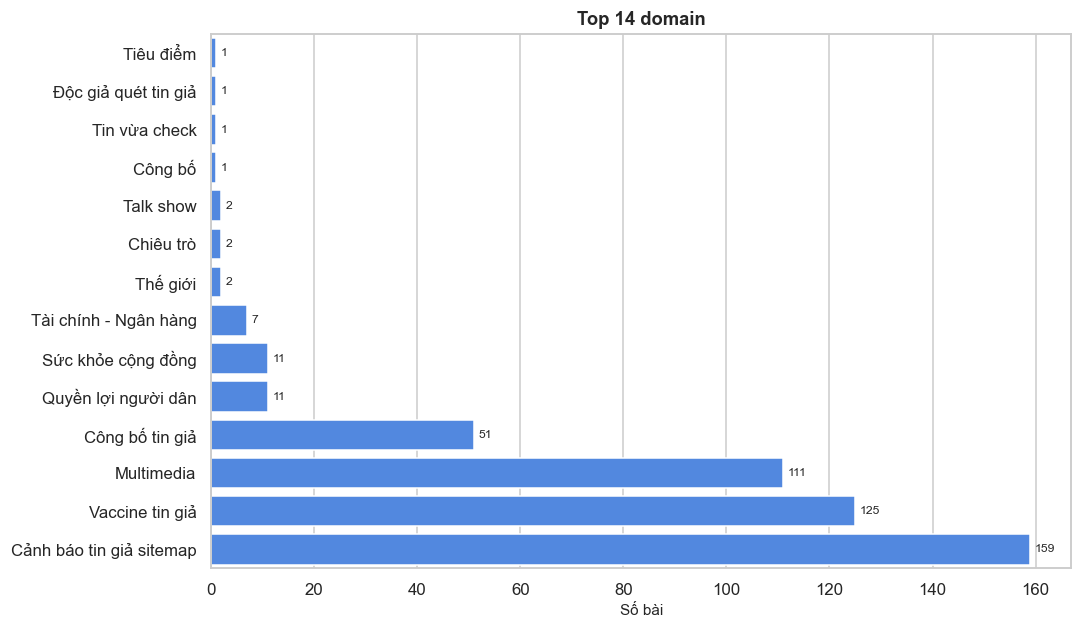

In [3]:
domain_counts = source_domain_analysis(df, atomic_domains)

## 3. Phân bố thời gian và domain theo năm

,trạng_thái_ngày,số_bài,tỷ_lệ
0,Hợp lệ,485,1.00
1,Thiếu/không parse được,0,0.00


,year,số_bài
0,2020,2
1,2021,166
2,2022,10
3,2023,33
4,2024,105
5,2025,166
6,2026,3


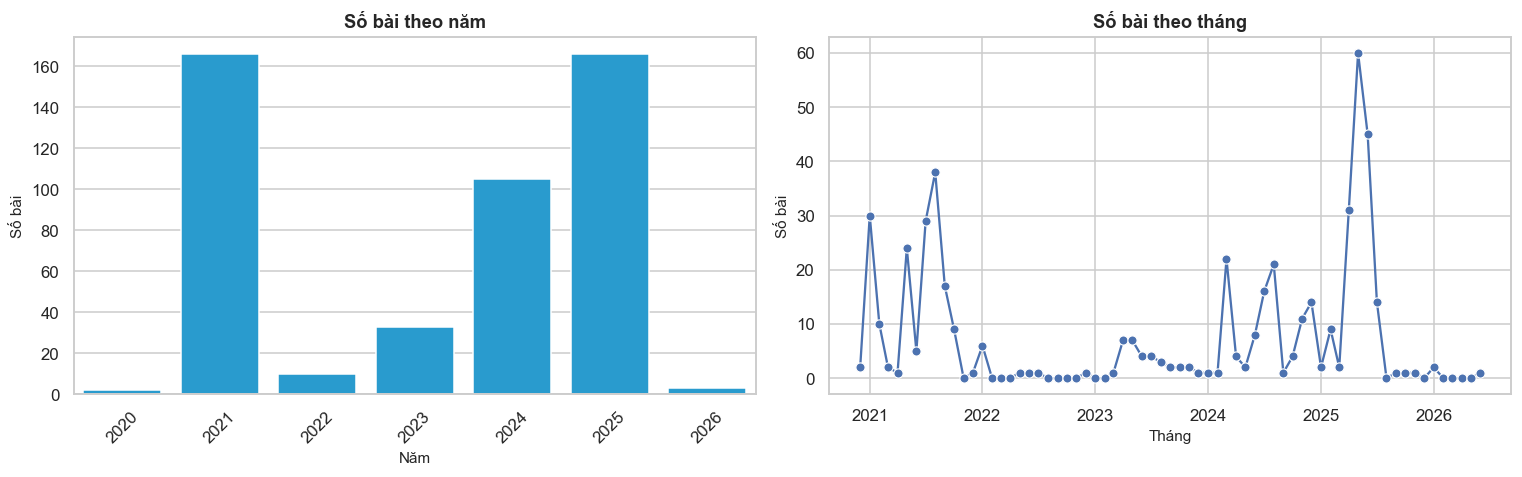

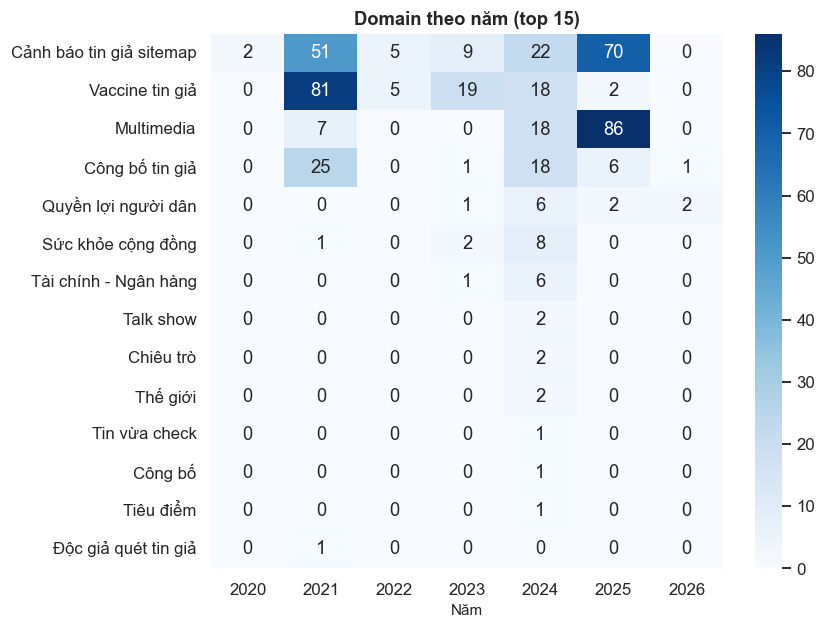

In [4]:
source_timeline(df, atomic_domains)

## 4. Chất lượng dữ liệu

,field,missing,missing_pct
0,comments,485,100.00
1,original_text,1,0.21
2,claim,0,0.00
3,domain,0,0.00
4,evidence,0,0.00
5,id,0,0.00
6,justification,0,0.00
7,label,0,0.00
8,publish_date,0,0.00
9,source_name,0,0.00


**Trùng lặp và URL**

,khóa,số_dòng_trùng,số_giá_trị_duy_nhất
0,id,0,485
1,url,0,485
2,claim,1,484
3,original_text,1,483


,chỉ_số,số_bài
0,URL HTTP(S) hợp lệ,485
1,URL không hợp lệ/thiếu,0
2,Ngày ở tương lai so với hôm nay,0
3,Bài có comments,0


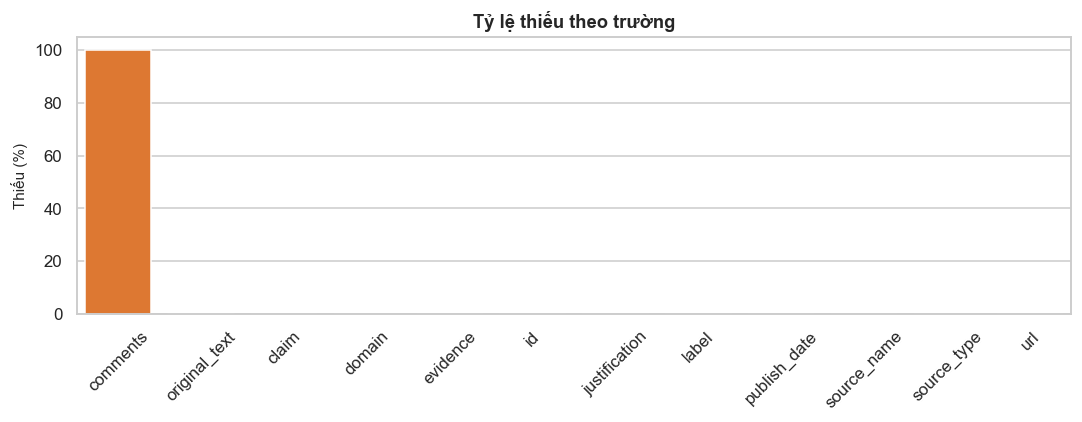

In [5]:
missing = source_quality_analysis(df)

## 5. Độ dài nội dung

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
trường,,,,,,,,,,,
claim_words,485.00,14.21,3.97,2.00,12.00,14.00,17.00,19.00,20.00,23.00,27.00
original_text_words,485.00,14.24,4.34,0.00,12.00,14.00,17.00,19.00,20.00,23.16,50.00
evidence_words,485.00,21.00,0.00,21.00,21.00,21.00,21.00,21.00,21.00,21.00,21.00
justification_words,485.00,495.02,444.84,33.00,255.00,407.00,615.00,930.00,"1,145.00","1,672.88","6,745.00"


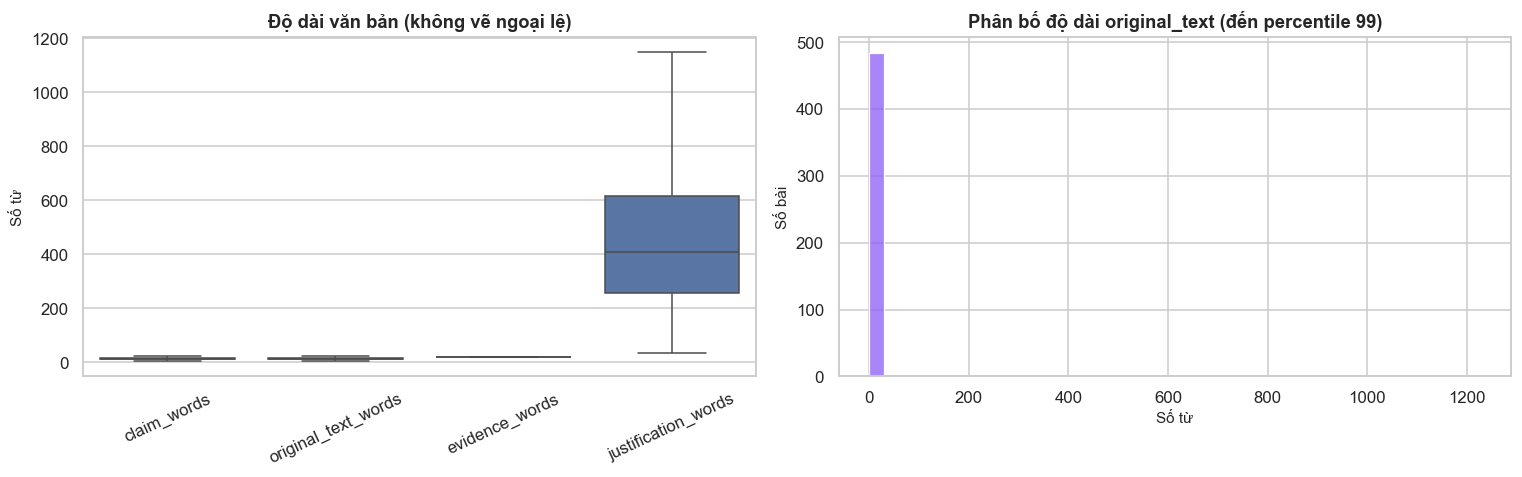

**Độ dài `original_text` theo top domain**

,số_bài,trung_vị,trung_bình,p90
domain_atomic,,,,
Vaccine tin giả,125,15.00,14.75,19.00
Chiêu trò,2,14.50,14.50,17.30
Thế giới,2,14.50,14.50,16.50
Cảnh báo tin giả sitemap,159,14.00,14.33,19.00
Multimedia,111,14.00,14.04,19.00
Công bố tin giả,51,14.00,13.51,20.00
Tin vừa check,1,14.00,14.00,14.00
Quyền lợi người dân,11,13.00,13.82,18.00
Sức khỏe cộng đồng,11,13.00,14.55,21.00


In [6]:
text_summary = source_text_analysis(df, atomic_domains)

## 6. Nhãn, loại nguồn và hostname

In [7]:
source_metadata_analysis(df)

**Nhãn**

,label,số_bài,tỷ_lệ
0,FALSE,485,1.00


**Loại nguồn**

,source_type,số_bài,tỷ_lệ
0,website,485,1.00


**Tên nguồn**

,source_name,số_bài,tỷ_lệ
0,VAFC,485,1.00


**Hostname**

,url_host,số_bài,tỷ_lệ
0,tingia.gov.vn,485,1.00


## 7. Mẫu bài theo domain và nhận xét

In [8]:
samples = source_samples(df, n_per_domain=2)
source_findings(df, atomic_domains)

,domain,publish_date,claim,label,url
0,Chiêu trò,2024-03-20,Làm cộng tác viên online bị lừa hơn 240 triệu đồng,FALSE,https://tingia.gov.vn/lam-cong-tac-vien-online-bi-lua-hon-240-trieu-dong.html
1,Chiêu trò,2024-08-22,Giả danh cán bộ Cục Hải quan để chiếm đoạt hàng tỷ đồng tiền đặt cọc mua xe,FALSE,https://tingia.gov.vn/gia-danh-can-bo-cuc-hai-quan-de-chiem-doat-hang-ty-dong-tien-dat-coc-mua-x...
2,Công bố,2024-06-12,"Khởi tố thêm 41 bị can trong vụ vẽ dự án ảo,",FALSE,https://tingia.gov.vn/khoi-to-them-41-bi-can-trong-vu-ve-du-an-ao-lua-khach-ve-dong-nai-mua-dat....
3,Công bố tin giả,2021-01-04,"Trang fanpage giả mạo VTV, đưa tin sai sự thật",FALSE,https://tingia.gov.vn/trang-fanpage-gia-mao-vtv-dua-tin-sai-su-that.html
4,Công bố tin giả,2021-01-04,Tin sai sự thật của tài khoản Faceboook Nguyen Dan về tài xế bán tải đánh người,FALSE,https://tingia.gov.vn/tin-sai-su-that-cua-tai-khoan-faceboook-nguyen-dan-ve-tai-xe-ban-tai-danh-...
5,Cảnh báo tin giả sitemap,2020-12-26,Tin sai sự thật về cơn bão số 5 - năm 2020,FALSE,https://tingia.gov.vn/tin-sai-su-that-ve-con-bao-so-5-nam-2020.html
6,Cảnh báo tin giả sitemap,2020-12-26,"Chia sẻ tin giả, Facebooker “Huấn Hoa Hồng” bị xử phạt 7,5 triệu đồng",FALSE,https://tingia.gov.vn/chia-se-tin-gia-facebooker-huan-hoa-hong-bi-xu-phat-7-5-trieu-dong.html
7,Multimedia,2021-01-13,Bị phạt 10 triệu đồng vì tung tin giả 'Phong tỏa TP.HCM 14 ngày,FALSE,https://tingia.gov.vn/bi-phat-10-trieu-dong-vi-tung-tin-gia-phong-toa-tp-hcm-14-ngay.html
8,Multimedia,2021-01-13,Bị xử phạt vì đưa tin giả về dịch bệnh,FALSE,https://tingia.gov.vn/bi-xu-phat-vi-dua-tin-gia-ve-dich-benh.html
9,Quyền lợi người dân,2023-11-10,Giả mạo phần mềm của Chính phủ để lừa đảo,FALSE,https://tingia.gov.vn/gia-mao-phan-mem-cua-chinh-phu-de-lua-dao.html


### Nhận xét tự động
- Có **485** bài và **14** domain sau khi tách.
- Domain lớn nhất là **Cảnh báo tin giả sitemap** với **159** lượt gán.
- Có **0** bài đa-domain và **0** bài thiếu/không parse được ngày.
- Phân bố nhãn: **FALSE: 485**.
- Các nhận xét này là mô tả dữ liệu, không phải kết luận về tính đại diện hay chất lượng nội dung.